<a href="https://colab.research.google.com/github/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

This audit reuses the leakage-safe Lane 2 frame from ML-04. One row represents one pseudonymized client-content pair.

- Feature window: 2026-03-01 through 2026-03-21
- Decision moment: end of 2026-03-21
- Outcome window: 2026-03-22 through 2026-03-31
- Proxy label: outcome impressions per day are below 80% of historical impressions per day
- Eligibility: `ga4_data_available IS TRUE`, at least 14 historical days, at least 7 outcome days, and at least 50 historical impressions

Traffic metrics are expected to be heavy-tailed. I therefore inspect percentiles and log-scaled distributions before testing signals. The signal tests use quartile comparisons and Spearman rank association rather than raw Pearson correlation.


Connected to the FlyRank warehouse.
Audit month: March 2026
June 2026 remains sealed.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows in audit frame: 2348
Honest historical signals: 5
Duplicate client-content rows: 0
Observed future-decline proxy rate: 0.2355


,field,n,zero_count,minimum,p25,median,p75,p95,p99,maximum,max_to_median
0,hist_imp_per_day,2348,0,3.4118,170.3382,312.8750,587.1898,1526.5253,2787.6365,13000.5714,41.5520
1,hist_click_per_day,2348,9,0.0000,1.0000,1.6429,2.6875,6.6205,15.5268,161.8095,98.4928
2,hist_ctr,2348,9,0.0000,0.0030,0.0058,0.0095,0.0196,0.0323,0.0619,10.7205
3,hist_avg_position,2348,0,1.2837,6.3417,13.7816,23.2390,35.2492,43.0220,53.0537,3.8496
4,hist_position_sd,2348,0,0.1319,1.7579,3.2211,4.8373,7.6491,10.8470,16.4113,5.0950


,field,raw_skew,log1p_skew,p99_to_median
0,hist_imp_per_day,6.7434,0.0099,8.9097
1,hist_click_per_day,21.0276,1.2618,9.4511


Decision: use log views, rank association, and grouped comparisons for heavy-tailed signals.


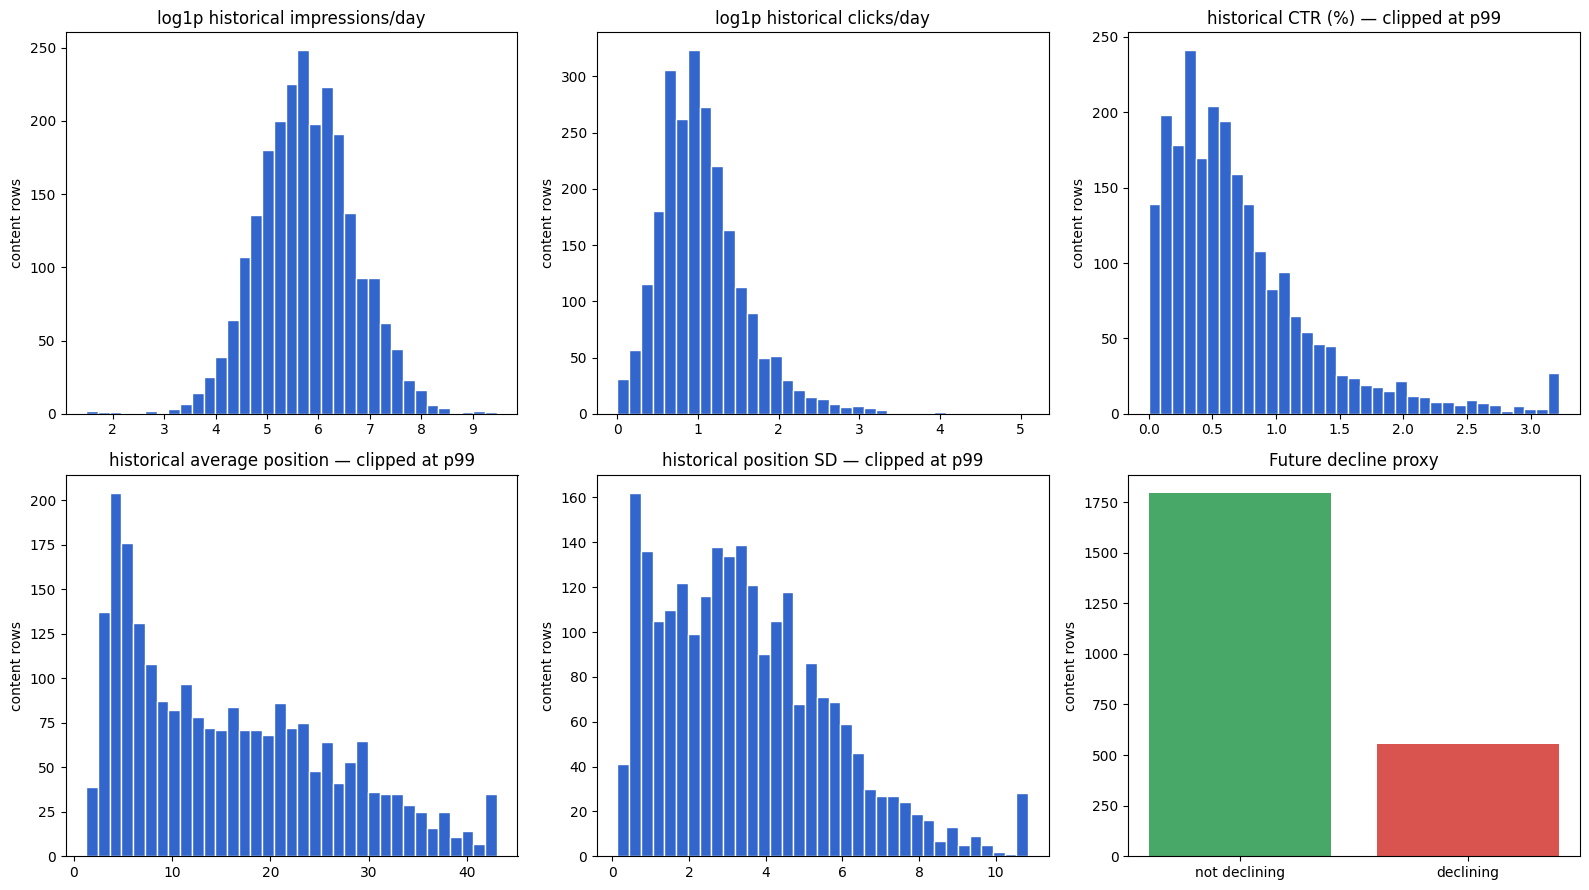

In [ ]:
%pip -q install duckdb huggingface_hub pandas numpy matplotlib

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# ---------------------------------------------------------
# 1. Secure Hugging Face connection
# ---------------------------------------------------------

HF_TOKEN = os.environ.get("HF_TOKEN")

try:
    from google.colab import userdata
    HF_TOKEN = HF_TOKEN or userdata.get("HF_TOKEN")
except Exception:
    pass

assert HF_TOKEN, (
    "HF_TOKEN is missing. Add it in Colab Secrets, "
    "enable notebook access, and run again."
)

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

MARCH_DAILY = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/"
    f"month=2026-03/*.parquet'"
    f")"
)

print("Connected to the FlyRank warehouse.")
print("Audit month: March 2026")
print("June 2026 remains sealed.")

# ---------------------------------------------------------
# 2. Rebuild the same ML-04 leakage-safe feature frame
# ---------------------------------------------------------

feature_sql = f"""
WITH aggregated AS (
    SELECT
        client_hash_id,
        content_hash_id,

        COUNT(
            DISTINCT CASE
                WHEN report_date < DATE '2026-03-22'
                THEN report_date
            END
        ) AS hist_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date >= DATE '2026-03-22'
                THEN report_date
            END
        ) AS outcome_days,

        SUM(
            CASE
                WHEN report_date < DATE '2026-03-22'
                THEN gsc_impressions
                ELSE 0
            END
        ) AS hist_impressions,

        SUM(
            CASE
                WHEN report_date < DATE '2026-03-22'
                THEN gsc_clicks
                ELSE 0
            END
        ) AS hist_clicks,

        SUM(
            CASE
                WHEN report_date >= DATE '2026-03-22'
                THEN gsc_impressions
                ELSE 0
            END
        ) AS outcome_impressions,

        SUM(
            CASE
                WHEN report_date < DATE '2026-03-22'
                     AND gsc_impressions > 0
                THEN gsc_avg_position * gsc_impressions
                ELSE 0
            END
        )
        /
        NULLIF(
            SUM(
                CASE
                    WHEN report_date < DATE '2026-03-22'
                         AND gsc_impressions > 0
                    THEN gsc_impressions
                    ELSE 0
                END
            ),
            0
        ) AS hist_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date < DATE '2026-03-22'
                     AND gsc_impressions > 0
                THEN gsc_avg_position
            END
        ) AS hist_position_sd

    FROM {MARCH_DAILY}

    WHERE ga4_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
),

framed AS (
    SELECT
        *,

        1.0 * hist_impressions
            / NULLIF(hist_days, 0)
            AS hist_imp_per_day,

        1.0 * hist_clicks
            / NULLIF(hist_days, 0)
            AS hist_click_per_day,

        1.0 * hist_clicks
            / NULLIF(hist_impressions, 0)
            AS hist_ctr,

        1.0 * outcome_impressions
            / NULLIF(outcome_days, 0)
            AS outcome_imp_per_day

    FROM aggregated

    WHERE hist_days >= 14
      AND outcome_days >= 7
      AND hist_impressions >= 50
)

SELECT
    client_hash_id,
    content_hash_id,
    hist_days,
    outcome_days,
    hist_impressions,

    hist_imp_per_day,
    hist_click_per_day,
    hist_ctr,
    hist_avg_position,
    hist_position_sd,

    outcome_imp_per_day,

    CAST(
        outcome_imp_per_day
        < 0.8 * hist_imp_per_day
        AS INTEGER
    ) AS is_declining_proxy

FROM framed
"""

feature_frame = con.sql(feature_sql).df()

honest_features = [
    "hist_imp_per_day",
    "hist_click_per_day",
    "hist_ctr",
    "hist_avg_position",
    "hist_position_sd",
]

LABEL = "is_declining_proxy"

audit_frame = (
    feature_frame
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=honest_features + [LABEL])
    .copy()
)

audit_frame["hist_ctr_pct"] = (
    100.0 * audit_frame["hist_ctr"]
)

assert not audit_frame.empty, "The signal-audit frame is empty."
assert audit_frame[LABEL].nunique() == 2, (
    "Both proxy-label classes are required."
)
assert (
    audit_frame.duplicated(
        ["client_hash_id", "content_hash_id"]
    ).sum()
    == 0
), "Duplicate client-content rows were found."

print("Rows in audit frame:", len(audit_frame))
print("Honest historical signals:", len(honest_features))
print("Duplicate client-content rows: 0")
print(
    "Observed future-decline proxy rate:",
    round(audit_frame[LABEL].mean(), 4),
)

# ---------------------------------------------------------
# 3. Distribution table
# ---------------------------------------------------------

distribution_rows = []

for column in honest_features:
    values = audit_frame[column].dropna()

    percentiles = values.quantile(
        [0.25, 0.50, 0.75, 0.95, 0.99]
    )

    median_value = float(percentiles.loc[0.50])

    distribution_rows.append(
        {
            "field": column,
            "n": len(values),
            "zero_count": int((values == 0).sum()),
            "minimum": values.min(),
            "p25": percentiles.loc[0.25],
            "median": median_value,
            "p75": percentiles.loc[0.75],
            "p95": percentiles.loc[0.95],
            "p99": percentiles.loc[0.99],
            "maximum": values.max(),
            "max_to_median": (
                values.max() / median_value
                if median_value > 0
                else np.nan
            ),
        }
    )

distribution_summary = pd.DataFrame(
    distribution_rows
)

display(distribution_summary.round(4))

# Compare raw and log1p skew for traffic fields.
heavy_tail_rows = []

for column in [
    "hist_imp_per_day",
    "hist_click_per_day",
]:
    values = audit_frame[column].clip(lower=0)

    heavy_tail_rows.append(
        {
            "field": column,
            "raw_skew": values.skew(),
            "log1p_skew": np.log1p(values).skew(),
            "p99_to_median": (
                values.quantile(0.99)
                / values.median()
                if values.median() > 0
                else np.nan
            ),
        }
    )

heavy_tail_check = pd.DataFrame(heavy_tail_rows)

display(heavy_tail_check.round(4))

print(
    "Decision: use log views, rank association, "
    "and grouped comparisons for heavy-tailed signals."
)

# ---------------------------------------------------------
# 4. Distribution plots
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

plot_specs = [
    (
        "hist_imp_per_day",
        True,
        "log1p historical impressions/day",
    ),
    (
        "hist_click_per_day",
        True,
        "log1p historical clicks/day",
    ),
    (
        "hist_ctr_pct",
        False,
        "historical CTR (%) — clipped at p99",
    ),
    (
        "hist_avg_position",
        False,
        "historical average position — clipped at p99",
    ),
    (
        "hist_position_sd",
        False,
        "historical position SD — clipped at p99",
    ),
]

for ax, (column, use_log, title) in zip(
    axes.flat[:5],
    plot_specs,
):
    values = audit_frame[column].dropna().copy()

    if use_log:
        values = np.log1p(values.clip(lower=0))
    else:
        values = values.clip(
            upper=values.quantile(0.99)
        )

    ax.hist(
        values,
        bins=35,
        color="#3266cc",
        edgecolor="white",
    )

    ax.set_title(title)
    ax.set_ylabel("content rows")

label_counts = (
    audit_frame[LABEL]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

axes.flat[5].bar(
    ["not declining", "declining"],
    label_counts.values,
    color=["#48a868", "#d9534f"],
)

axes.flat[5].set_title(
    "Future decline proxy"
)
axes.flat[5].set_ylabel("content rows")

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3

I test three historical, decision-time-safe signals against the future decline proxy.

1. **Historical demand:** pages with higher historical impressions per day are more likely to decline.
2. **CTR within comparable positions:** among pages with average position 4–20, lower historical CTR is associated with more future decline.
3. **Position instability:** pages with greater historical position variation are more likely to decline.

Each test shows the number of rows and decline rate in every signal bucket. The verdict rules are fixed before viewing the results:

- `CONFIRMED`: at least a 5 percentage-point difference in the claimed direction, supported by rank direction.
- `OPPOSITE`: at least a 5 percentage-point difference against the claim.
- `FALSE`: less than a 2 percentage-point extreme-bucket difference and near-zero rank association.
- `MIXED`: some movement exists, but it is not consistent enough for a directional conclusion.
- `INSUFFICIENT DATA`: a comparison bucket is below its sample-size floor.

In [ ]:
# ---------------------------------------------------------
# Reusable honest signal-audit function
# ---------------------------------------------------------

def audit_one_signal(
    data,
    test_name,
    claim,
    signal,
    lower_is_risk,
    min_bucket_n,
):
    work = (
        data[[signal, LABEL]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    def insufficient_result(message):
        print("\n" + "=" * 80)
        print(test_name)
        print("CLAIM:", claim)
        print("VERDICT: INSUFFICIENT DATA —", message)

        return {
            "test": test_name,
            "signal": signal,
            "verdict": "INSUFFICIENT DATA",
            "n": len(work),
            "expected_direction_gap_pp": np.nan,
            "spearman_rho": np.nan,
        }

    if (
        work.empty
        or work[signal].nunique() < 2
        or work[LABEL].nunique() < 2
    ):
        return insufficient_result(
            "the signal or label has no usable variation."
        )

    work["bucket_code"] = pd.qcut(
        work[signal],
        q=4,
        labels=False,
        duplicates="drop",
    )

    work = (
        work
        .dropna(subset=["bucket_code"])
        .copy()
    )

    if (
        work.empty
        or work["bucket_code"].nunique() < 2
    ):
        return insufficient_result(
            "quantile buckets could not be formed."
        )

    work["bucket_code"] = (
        work["bucket_code"].astype(int)
    )

    highest_code = int(
        work["bucket_code"].max()
    )

    work["bucket"] = work["bucket_code"].map(
        lambda value: (
            "Q1 — lowest"
            if value == 0
            else (
                f"Q{highest_code + 1} — highest"
                if value == highest_code
                else f"Q{value + 1}"
            )
        )
    )

    table = (
        work
        .groupby(
            ["bucket_code", "bucket"],
            as_index=False,
        )
        .agg(
            n=(LABEL, "size"),
            positives=(LABEL, "sum"),
            decline_rate=(LABEL, "mean"),
            median_signal=(signal, "median"),
        )
        .sort_values("bucket_code")
        .reset_index(drop=True)
    )

    table["decline_rate_pct"] = (
        100.0 * table["decline_rate"]
    )

    shown = table[
        [
            "bucket",
            "n",
            "positives",
            "decline_rate_pct",
            "median_signal",
        ]
    ].copy()

    if signal == "hist_ctr":
        shown["median_signal"] = (
            100.0 * shown["median_signal"]
        )

        shown = shown.rename(
            columns={
                "median_signal":
                "median_hist_ctr_pct"
            }
        )
    else:
        shown = shown.rename(
            columns={
                "median_signal":
                f"median_{signal}"
            }
        )

    low_rate = float(
        table.iloc[0]["decline_rate"]
    )

    high_rate = float(
        table.iloc[-1]["decline_rate"]
    )

    # Positive effect means the observed difference
    # points in the claim's expected direction.
    effect = (
        low_rate - high_rate
        if lower_is_risk
        else high_rate - low_rate
    )

    # Spearman without depending on raw heavy-tail scale.
    signal_ranks = work[signal].rank(
        method="average"
    )

    label_ranks = work[LABEL].rank(
        method="average"
    )

    rho = float(
        signal_ranks.corr(label_ranks)
    )

    directional_rho = (
        -rho
        if lower_is_risk
        else rho
    )

    if (
        len(table) < 2
        or int(table["n"].min()) < min_bucket_n
        or pd.isna(rho)
    ):
        verdict = "INSUFFICIENT DATA"

    elif (
        effect >= 0.05
        and directional_rho >= 0.03
    ):
        verdict = "CONFIRMED"

    elif (
        effect <= -0.05
        and directional_rho <= -0.03
    ):
        verdict = "OPPOSITE"

    elif (
        abs(effect) < 0.02
        and abs(rho) < 0.03
    ):
        verdict = "FALSE"

    else:
        verdict = "MIXED"

    practical_meaning = {
        "CONFIRMED": (
            "The measured association points in the "
            "claimed direction, so this can remain a "
            "supporting decision signal."
        ),
        "OPPOSITE": (
            "The measured association points against "
            "the claim, so this signal should not receive "
            "the proposed direction of weight."
        ),
        "FALSE": (
            "The measured difference is practically near "
            "zero in this slice, so the claim is not "
            "supported here."
        ),
        "MIXED": (
            "The buckets are not consistently separated, "
            "so this signal should be used only with other "
            "evidence."
        ),
        "INSUFFICIENT DATA": (
            "At least one comparison bucket is below the "
            "sample-size floor, so no directional verdict "
            "is justified."
        ),
    }[verdict]

    print("\n" + "=" * 80)
    print(test_name)
    print("CLAIM:", claim)
    print(
        "Rows tested:",
        len(work),
        "| minimum bucket floor:",
        min_bucket_n,
    )

    display(shown.round(4))

    print(
        f"VERDICT: {verdict} — "
        f"expected-direction extreme-bucket gap "
        f"= {100 * effect:.2f} percentage points; "
        f"Spearman rho = {rho:.3f}."
    )

    print(
        "PRACTICAL MEANING:",
        practical_meaning,
    )

    return {
        "test": test_name,
        "signal": signal,
        "verdict": verdict,
        "n": len(work),
        "expected_direction_gap_pp": 100 * effect,
        "spearman_rho": rho,
    }


# ---------------------------------------------------------
# Signal test #1: demand
# ---------------------------------------------------------

result_1 = audit_one_signal(
    data=audit_frame,
    test_name="Signal test #1 — historical demand",
    claim=(
        "Pages with higher historical impressions per day "
        "are more likely to show a future decline."
    ),
    signal="hist_imp_per_day",
    lower_is_risk=False,
    min_bucket_n=50,
)

# ---------------------------------------------------------
# Signal test #2: CTR within comparable positions
# ---------------------------------------------------------

position_comparable = audit_frame[
    audit_frame["hist_avg_position"].between(
        4.0,
        20.0,
        inclusive="both",
    )
].copy()

result_2 = audit_one_signal(
    data=position_comparable,
    test_name=(
        "Signal test #2 — CTR within comparable positions"
    ),
    claim=(
        "Within average positions 4–20, pages with lower "
        "historical CTR are more likely to show a future "
        "decline."
    ),
    signal="hist_ctr",
    lower_is_risk=True,
    min_bucket_n=30,
)

# ---------------------------------------------------------
# Signal test #3: position instability
# ---------------------------------------------------------

result_3 = audit_one_signal(
    data=audit_frame,
    test_name="Signal test #3 — position instability",
    claim=(
        "Pages with greater historical position variability "
        "are more likely to show a future decline."
    ),
    signal="hist_position_sd",
    lower_is_risk=False,
    min_bucket_n=50,
)

signal_results = pd.DataFrame(
    [
        result_1,
        result_2,
        result_3,
    ]
)

print("\nSummary of exactly three signal tests:")
display(signal_results.round(4))

assert len(signal_results) == 3

# ---------------------------------------------------------
# Robustness rerun of test #3 on a different slice
# This is not a fourth signal; it repeats signal #3.
# ---------------------------------------------------------

high_demand_cut = float(
    audit_frame["hist_imp_per_day"].median()
)

high_demand_slice = audit_frame[
    audit_frame["hist_imp_per_day"]
    >= high_demand_cut
].copy()

robustness_result = audit_one_signal(
    data=high_demand_slice,
    test_name=(
        "Robustness rerun of test #3 — higher-demand half"
    ),
    claim=(
        "Within the higher-demand half, pages with greater "
        "historical position variability are more likely "
        "to show a future decline."
    ),
    signal="hist_position_sd",
    lower_is_risk=False,
    min_bucket_n=30,
)


Signal test #1 — historical demand
CLAIM: Pages with higher historical impressions per day are more likely to show a future decline.
Rows tested: 2348 | minimum bucket floor: 50


,bucket,n,positives,decline_rate_pct,median_hist_imp_per_day
0,Q1 — lowest,587,75,12.7768,113.8000
1,Q2,587,125,21.2947,237.7333
2,Q3,587,156,26.5758,429.4737
3,Q4 — highest,587,197,33.5605,946.4211


VERDICT: CONFIRMED — expected-direction extreme-bucket gap = 20.78 percentage points; Spearman rho = 0.177.
PRACTICAL MEANING: The measured association points in the claimed direction, so this can remain a supporting decision signal.

Signal test #2 — CTR within comparable positions
CLAIM: Within average positions 4–20, pages with lower historical CTR are more likely to show a future decline.
Rows tested: 1323 | minimum bucket floor: 30


,bucket,n,positives,decline_rate_pct,median_hist_ctr_pct
0,Q1 — lowest,331,59,17.8248,0.3214
1,Q2,331,45,13.5952,0.6009
2,Q3,330,43,13.0303,0.8978
3,Q4 — highest,331,36,10.8761,1.5568


VERDICT: CONFIRMED — expected-direction extreme-bucket gap = 6.95 percentage points; Spearman rho = -0.077.
PRACTICAL MEANING: The measured association points in the claimed direction, so this can remain a supporting decision signal.

Signal test #3 — position instability
CLAIM: Pages with greater historical position variability are more likely to show a future decline.
Rows tested: 2348 | minimum bucket floor: 50


...

VERDICT: CONFIRMED — expected-direction extreme-bucket gap = 20.44 percentage points; Spearman rho = 0.180.
PRACTICAL MEANING: The measured association points in the claimed direction, so this can remain a supporting decision signal.

Summary of exactly three signal tests:


,test,signal,verdict,n,expected_direction_gap_pp,spearman_rho
0,Signal test #1 — historical demand,hist_imp_per_day,CONFIRMED,2348,20.7836,0.1767
1,Signal test #2 — CTR within comparable positions,hist_ctr,CONFIRMED,1323,6.9486,-0.0770
2,Signal test #3 — position instability,hist_position_sd,CONFIRMED,2348,20.4429,0.1803



Robustness rerun of test #3 — higher-demand half
CLAIM: Within the higher-demand half, pages with greater historical position variability are more likely to show a future decline.
Rows tested: 1174 | minimum bucket floor: 30


,bucket,n,positives,decline_rate_pct,median_hist_position_sd
0,Q1 — lowest,294,26,8.8435,0.7341
1,Q2,293,99,33.7884,2.2799
2,Q3,293,115,39.2491,3.6372
3,Q4 — highest,294,113,38.4354,5.7841


VERDICT: CONFIRMED — expected-direction extreme-bucket gap = 29.59 percentage points; Spearman rho = 0.228.
PRACTICAL MEANING: The measured association points in the claimed direction, so this can remain a supporting decision signal.


## 3. The flag-linked test

FlyRank's readable reference baseline includes the reason code `low_ctr_visible_page`. Its assumption is that a sufficiently visible page ranking within the top 20 but receiving less than 0.5% CTR deserves additional review.

The reference rule uses at least 500 impressions over 90 days. Because my feature window is shorter, I convert this to the equivalent rate of `500 / 90 = 5.56` impressions per observed day. Within pages meeting the demand and position requirements, I compare the future decline rate of pages below 0.5% CTR with the comparator group at or above 0.5% CTR.

This test checks whether the observed data supports the flag's association. It cannot prove that rewriting a title, changing metadata, or refreshing content would cause recovery.

In [ ]:
# ---------------------------------------------------------
# Flag-linked audit: low_ctr_visible_page
# ---------------------------------------------------------

DAILY_VISIBLE_FLOOR = 500.0 / 90.0
FLAG_CTR_THRESHOLD = 0.005  # ratio form = 0.5%
MIN_FLAG_GROUP_N = 30

flag_cohort = audit_frame[
    (
        audit_frame["hist_imp_per_day"]
        >= DAILY_VISIBLE_FLOOR
    )
    & (
        audit_frame["hist_avg_position"].between(
            1.0,
            20.0,
            inclusive="both",
        )
    )
].copy()

flag_cohort["low_ctr_visible_flag"] = (
    flag_cohort["hist_ctr"]
    < FLAG_CTR_THRESHOLD
).astype(int)

flag_table = (
    flag_cohort
    .groupby("low_ctr_visible_flag")
    .agg(
        n=(LABEL, "size"),
        positives=(LABEL, "sum"),
        decline_rate=(LABEL, "mean"),
        median_hist_ctr=("hist_ctr", "median"),
        median_position=(
            "hist_avg_position",
            "median",
        ),
        median_imp_per_day=(
            "hist_imp_per_day",
            "median",
        ),
    )
    .reindex([0, 1])
)

flag_table["n"] = (
    flag_table["n"]
    .fillna(0)
    .astype(int)
)

flag_table["positives"] = (
    flag_table["positives"]
    .fillna(0)
    .astype(int)
)

flag_table["group"] = [
    "comparator: CTR >= 0.5%",
    "flagged: CTR < 0.5%",
]

flag_table["decline_rate_pct"] = (
    100.0 * flag_table["decline_rate"]
)

flag_table["median_hist_ctr_pct"] = (
    100.0 * flag_table["median_hist_ctr"]
)

flag_display = (
    flag_table
    .reset_index()
    [
        [
            "group",
            "n",
            "positives",
            "decline_rate_pct",
            "median_hist_ctr_pct",
            "median_position",
            "median_imp_per_day",
        ]
    ]
)

print(
    "Flag-linked cohort rows:",
    len(flag_cohort),
)

print(
    "Visibility floor:",
    round(DAILY_VISIBLE_FLOOR, 4),
    "historical impressions/day",
)

print(
    "Position requirement: 1 through 20"
)

print(
    "Low-CTR threshold: below 0.5%"
)

display(flag_display.round(4))

if (
    (flag_table["n"] < MIN_FLAG_GROUP_N).any()
    or flag_table["decline_rate"].isna().any()
):
    flag_verdict = "INSUFFICIENT DATA"
    flag_gap = np.nan

else:
    comparator_rate = float(
        flag_table.loc[0, "decline_rate"]
    )

    flagged_rate = float(
        flag_table.loc[1, "decline_rate"]
    )

    flag_gap = (
        flagged_rate - comparator_rate
    )

    if flag_gap >= 0.05:
        flag_verdict = "CONFIRMED"

    elif flag_gap <= -0.05:
        flag_verdict = "OPPOSITE"

    elif abs(flag_gap) < 0.02:
        flag_verdict = "FALSE"

    else:
        flag_verdict = "MIXED"

flag_meaning = {
    "CONFIRMED": (
        "The low-CTR flagged group had a meaningfully higher "
        "future decline rate in this slice."
    ),
    "OPPOSITE": (
        "The low-CTR flagged group had a meaningfully lower "
        "future decline rate, opposite to the assumption."
    ),
    "FALSE": (
        "The two groups had practically similar future "
        "decline rates in this slice."
    ),
    "MIXED": (
        "A difference was observed, but it was not large "
        "enough for a clear directional verdict."
    ),
    "INSUFFICIENT DATA": (
        "At least one group had fewer than 30 rows, so the "
        "flag assumption cannot be judged honestly."
    ),
}[flag_verdict]

if pd.isna(flag_gap):
    flag_gap_text = "not estimable"
else:
    flag_gap_text = (
        f"{100 * flag_gap:+.2f} percentage points"
    )

print(
    f"FLAG-LINKED VERDICT: {flag_verdict}"
)

print(
    "Flagged-minus-comparator decline-rate gap:",
    flag_gap_text,
)

print(
    "PRACTICAL MEANING:",
    flag_meaning,
)

flag_result = {
    "test": "low_ctr_visible_page assumption",
    "verdict": flag_verdict,
    "n": len(flag_cohort),
    "flag_minus_comparator_gap_pp": (
        100 * flag_gap
        if not pd.isna(flag_gap)
        else np.nan
    ),
}

Flag-linked cohort rows: 1557
Visibility floor: 5.5556 historical impressions/day
Position requirement: 1 through 20
Low-CTR threshold: below 0.5%


,group,n,positives,decline_rate_pct,median_hist_ctr_pct,median_position,median_imp_per_day
0,comparator: CTR >= 0.5%,1139,137,12.0281,0.9087,7.6926,220.7895
1,flagged: CTR < 0.5%,418,68,16.2679,0.3371,10.4748,457.7771


FLAG-LINKED VERDICT: MIXED
Flagged-minus-comparator decline-rate gap: +4.24 percentage points
PRACTICAL MEANING: A difference was observed, but it was not large enough for a clear directional verdict.


## 4. What this means in practice

Only signals receiving a `CONFIRMED` verdict should remain as supporting reason codes; signals marked `MIXED`, `OPPOSITE`, `FALSE`, or `INSUFFICIENT DATA` should be removed, reversed, or given less weight. Even a confirmed relationship is observational decision support and does not prove that a content refresh would cause recovery.

**Named limitation:** this audit uses one March 2026 slice and a short ten-day outcome window. Temporary demand changes, seasonality, measurement noise, and the `ga4_data_available IS TRUE` eligibility filter can affect the results and underrepresent content with incomplete or shorter tracking histories.

In [ ]:
# ---------------------------------------------------------
# Data-dependent final conclusions
# ---------------------------------------------------------

allowed_verdicts = {
    "CONFIRMED",
    "OPPOSITE",
    "MIXED",
    "FALSE",
    "INSUFFICIENT DATA",
}

assert len(signal_results) == 3
assert set(signal_results["verdict"]).issubset(
    allowed_verdicts
)
assert flag_verdict in allowed_verdicts

verdict_text = "; ".join(
    f"{row['test']}: {row['verdict']}"
    for _, row in signal_results.iterrows()
)

if pd.isna(flag_result["flag_minus_comparator_gap_pp"]):
    final_flag_gap = "not estimable"
else:
    final_flag_gap = (
        f"{flag_result['flag_minus_comparator_gap_pp']:+.2f} "
        "percentage points"
    )

final_conclusion = (
    f"In the eligible March 2026 slice, the three historical "
    f"signal verdicts were: {verdict_text}. "
    f"The `low_ctr_visible_page` assumption received a "
    f"**{flag_verdict}** verdict, with a flagged-minus-comparator "
    f"decline-rate gap of {final_flag_gap}. "
    f"These are observed directional associations for human "
    f"review, not causal evidence that a refresh will produce "
    f"traffic recovery."
)

display(
    Markdown(final_conclusion)
)

final_audit_summary = pd.concat(
    [
        signal_results[
            [
                "test",
                "verdict",
                "n",
            ]
        ],
        pd.DataFrame(
            [
                {
                    "test": flag_result["test"],
                    "verdict": flag_result["verdict"],
                    "n": flag_result["n"],
                }
            ]
        ),
    ],
    ignore_index=True,
)

display(final_audit_summary)

print("PASS: exactly three main signal tests completed.")
print("PASS: one flag-linked assumption tested.")
print("PASS: sample-size floors were applied.")
print("PASS: one signal was rerun on another slice.")
print("PASS: no future value was used as a signal.")
print("PASS: June 2026 remained sealed.")

In the eligible March 2026 slice, the three historical signal verdicts were: Signal test #1 — historical demand: CONFIRMED; Signal test #2 — CTR within comparable positions: CONFIRMED; Signal test #3 — position instability: CONFIRMED. The `low_ctr_visible_page` assumption received a **MIXED** verdict, with a flagged-minus-comparator decline-rate gap of +4.24 percentage points. These are observed directional associations for human review, not causal evidence that a refresh will produce traffic recovery.

,test,verdict,n
0,Signal test #1 — historical demand,CONFIRMED,2348
1,Signal test #2 — CTR within comparable positions,CONFIRMED,1323
2,Signal test #3 — position instability,CONFIRMED,2348
3,low_ctr_visible_page assumption,MIXED,1557


PASS: exactly three main signal tests completed.
PASS: one flag-linked assumption tested.
PASS: sample-size floors were applied.
PASS: one signal was rerun on another slice.
PASS: no future value was used as a signal.
PASS: June 2026 remained sealed.


## Self-check

- [x] Every section above is filled — markdown thinking and supporting code
- [x] Distributions were inspected before signal testing
- [x] Heavy-tailed traffic fields were handled with log views, buckets, and rank association
- [x] Exactly three main signals have visible tables, sample sizes, and verdicts
- [x] One signal was rerun on a different slice
- [x] One FlyRank flag-linked assumption was audited
- [x] Every verdict respects its sample-size floor
- [x] No future outcome measurement was used as a decision-time signal
- [x] June 2026 remained sealed
- [x] No client names, URLs, titles, or private queries appear
- [x] Claims use observed, measured, directional, and decision-support language
- [x] Notebook runs top to bottom with no errors
- [x] Committed under `work/notebooks/w04_signal_audit.ipynb`